# MVP — Machine Learning & Analytics

- **Nome:** Raphael de Almeida Rocha
- **Matrícula:** 4052026000499
- **Data:** 01/07/2026
- **Dataset:** - [Kaggle - Video Games Playtime Duration Dataset](https://www.kaggle.com/datasets/b4n4n4p0wer/how-long-to-beat-video-game-playtime-dataset?select=hltb_dataset.csv)
- **Tipo de problema:** Regressão  

---


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☒ |
| Dataset descrito, com fonte, atributos e restrições | ☒ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☒ |
| Análise exploratória objetiva, conectada à modelagem | ☒ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☒ |
| Prevenção de vazamento de dados | ☒ |
| Tratamentos de dados justificados | ☒ |
| Pipeline ou sequência reprodutível de pré-processamento | ☒ |
| Modelo baseline definido | ☒ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☒ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☒ |
| Avaliação com métricas coerentes com o problema | ☒ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☒ |
| Código limpo, organizado e executável do início ao fim | ☒ |
| Conclusão conectada ao objetivo inicial | ☒ |



# 1.0 Definição do problema

## 1.1 Descrição do problema

Desenvolvedores independentes frequentemente iniciam o desenvolvimento de seus jogos movidos por ideias criativas e mecânicas inovadoras. No entanto, durante a fase de planejamento, pode ser desafiador definir o escopo de conteúdo do jogo sem ter referências claras. Saber se a aventura que estão criando está muito curta ou longa demais em relação a jogos semelhantes requer muita pesquisa manual.
A ideia é usar dados históricos para responder a uma dúvida comum no planejamento: "Se eu for produzir um jogo com essas características e gêneros específicos, qual é a média de horas de duração que os títulos similares entregam?".

- **Contexto do problema**: Planejamento de escopo e definição de metas de duração para pequenos projetos de jogos eletrônicos.
- **Qual analise o modelo deve apoiar?** Apoiar a Estimativa de horas da campanha principal, servindo como uma referência estatística baseada no que já foi lançado.
- **Quem são os interessados?** Pequenos desenvolvedores independentes, estudantes de design de jogos e entusiastas que estão estruturando seus primeiros projetos comerciais.
- **Porque o este problema é relevante?** Porque ajuda a ancorar a criatividade do desenvolvedor na realidade dos dados, fornecendo um parâmetro rápido e confiável sobre o tamanho esperado para o jogo.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de regressão em Machine Learning para prever a estimativa de tempo da campanha principal de um jogo, fornecendo aos desenvolvedores indies uma métrica de referência baseada em características como gênero e plataforma. Compararemos um modelo baseline com algoritmos lineares e baseados em árvores.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** A variável alvo, `main_story`, é um valor numérico contínuo (horas de jogo). Queremos prever o valor mais próximo possível da realidade, e não classificar o jogo em categorias isoladas.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses**

**1ª Hipótese:** Jogos que contém a tag "RPG" têm uma duração média consistentemente maior do que gêneros de partidas rápidas, independentemente de serem indie ou AAA.

**2ª Hipótese:** O ano de lançamento (release_year) pode mostrar se a tendência geral do mercado é aumentar ou diminuir a duração das campanhas ao longo do tempo.

**3ª Hipótese:** O número de plataformas em que o jogo é lançado influencia a duração, sendo que jogos muito específicos (ex: apenas uma plataforma) podem ter durações mais de nicho.

**Critérios de sucesso:**
- **Métrica principal:** RMSE, MAE
- **Resultado mínimo esperado:** Que os modelos de Machine Learning apresentem um erro (MAE/RMSE) menor do que simplesmente adivinhar usando a media (o baseline), comprovando que os dados de gênero e plataforma trazem padrão preditivo útil.


- **Restrição prática:** Simplicidade e Baixo Custo Computacional, O modelo deve ser leve e capaz de rodar rapidamente em um computador convencional, utilizando bibliotecas de código aberto padrão.


# 2.0 Ambiente, bibliotecas e reprodutibilidade


In [2]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Validação e Seleção de Modelos
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

#Pré-processamento e Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#Modelos de Regressão
from sklearn.dummy import DummyRegressor #Baseline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#Métricas de Avaliação para Regressão
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

#Configuração visual do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Versão do Python:", sys.version.split()[0])
print("SEED Configurada:", SEED)

Versão do Python: 3.12.13
SEED Configurada: 42


## 2.1 Dependências adicionais



## 2.2 Funções auxiliares

In [3]:
#Calcula Metrica da Regressão
def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }
#Exite Resultado em dataframe
def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T

#Padronização da coluna publishers
def Padroniza_publishers(name):

    publisher_mapping = {
            'BANDAI': 'BANDAI NAMCO',
            'NAMCO': 'BANDAI NAMCO',
            'SONY': 'SONY',
            'PLAYSTATION': 'SONY',
            'SQUARE': 'SQUARE ENIX',
            'ENIX': 'SQUARE ENIX',
            'EA ': 'ELECTRONIC ARTS',
            'ELECTRONIC ARTS': 'ELECTRONIC ARTS',
            'UBISOFT': 'UBISOFT',
            'NINTENDO': 'NINTENDO',
            'SEGA': 'SEGA',
            'CAPCOM': 'CAPCOM',
            'MICROSOFT': 'MICROSOFT / XBOX',
            'XBOX': 'MICROSOFT / XBOX',
            'KONAMI': 'KONAMI',
            'WARNER': 'WARNER BROS',
            'WB GAMES': 'WARNER BROS',
            'ACTIVISION': 'ACTIVISION BLIZZARD',
            'BLIZZARD': 'ACTIVISION BLIZZARD',
            'BETHESDA': 'BETHESDA',
            'TAKE-TWO': 'TAKE-TWO INTERACTIVE',
            'ROCKSTAR': 'TAKE-TWO INTERACTIVE',
            '2K ': 'TAKE-TWO INTERACTIVE'
    }
    #Procura a palavra-chave no mapeamento
    for key, official_name in publisher_mapping.items():
          if key in str(name):
                return official_name
    return str(name).title()

#Função para listar as colunas que devem ser descartadas
def lista_colunas_descartadas():
    return [
        'id', 'name','developer','release_month','release_day',
        'release_precision', 'release_date','main_story_polled',
        'main_plus_sides_polled', 'main_plus_sides','completionist_polled',
        'completionist', 'all_styles_polled', 'all_styles', 'single_player_polled',
        'single_player', 'co_op_polled', 'co_op','versus_polled', 'versus',
        'source_url', 'crawled_at'
    ]
#Retira caracteres especiais
def padronizar_textos(texto):
    if pd.isna(texto):
        return texto

    texto = str(texto).upper()
    texto = texto.replace("-", " ")
    texto = texto.strip()
    return texto

#Função para executar a limpeza das colunas não utilizadas
def limpeza_game_data(Dados):

    Dados_limpeza = Dados.copy()

    #Filtra apenas por Game na coluna Type
    if 'type' in Dados_limpeza.columns:
        Dados_limpeza = Dados_limpeza[Dados_limpeza['type'] == 'game']

    #Limpeza dos dados que estão sem informações na coluna Main_Story
    if 'main_story' in Dados_limpeza.columns:
        Dados_limpeza = Dados_limpeza.dropna(subset=['main_story'])

    #Tratar a coluna plataforma
    if 'platform' in Dados_limpeza.columns:
            Dados_limpeza['platform'] = Dados_limpeza['platform'].fillna('Desconhecido')
            #Conta a quantidade de virgulas
            Dados_limpeza['num_plataformas'] = Dados_limpeza['platform'].apply(lambda x: len(str(x).split(',')))
            #Mantem so o primeiro console
            Dados_limpeza['platform'] = Dados_limpeza['platform'].apply(lambda x: str(x).split(',')[0].strip())
            Dados_limpeza['platform'] = Dados_limpeza['platform'].apply(padronizar_textos)

    #Tratar a coluna genero
    if 'genres' in Dados_limpeza.columns:
        Dados_limpeza['genres'] = Dados_limpeza['genres'].fillna('Outros')
        Dados_limpeza['genres'] = Dados_limpeza['genres'].apply(
            lambda x: str(x).split(',')[0].strip()
        )

        # Padroniza os textos
        Dados_limpeza['genres'] = Dados_limpeza['genres'].apply(padronizar_textos)

        # Corrige as variações de valores na coluna genres
        correcoes_manuais = {
            'ROLE PLAYING GAME': 'RPG',
            'ROLE PLAYING': 'RPG',
            'ACTION ROLE PLAYING': 'ACTION RPG',
            'ACTION ROLE PLAYING GAME': 'ACTION RPG',
            "ARCADE/SHOOT 'EM UP": 'ARCADE SHOOTER',
            "SHOOT 'EM UP": 'SHOOT EM UP',
            'CARD': 'CARD GAME',
            'FIGHTING GAME': 'FIGHTING',
            'FIRST PERSON': 'FPS',
            'FIRST PERSON SHOOTER': 'FPS',
            'FIRST PESON': 'FPS',
            'LIGHT GUN': 'LIGHT GUN SHOOTER',
            'MULTI DIRECTIONAL SHOOTER': 'MULTIDIRECTIONAL SHOOTER',
            'PLATFORM': 'PLATFORMER',
            'PLATFORM GAME': 'PLATFORMER',
            'PLATFORMING': 'PLATFORMER',
            'PROFESSIONAL WRESTLING FIGHTING': 'PROFESSIONAL WRESTLING',
            'REAL TIME TACTICAL RPG': 'REAL TIME TACTICS',
            'TACTICAL ROLE PLAYING': 'TACTICAL RPG',
            'SIDE': 'SIDE SCROLLER',
            'SPACE COMBAT': 'SPACE COMBAT SIMULATOR',
            'SPACE SIMULATION': 'SPACE SIMULATOR',
            'SPORT': 'SPORTS',
            'STEATH': 'STEALTH',
            'STEALTH BASED GAME': 'STEALTH',
            'VEHICLE COMBAT': 'VEHICULAR COMBAT',
            'VERTICAL SCROLLING SHOOTER': 'VERTICAL SHOOTER'
        }
        Dados_limpeza['genres'] = Dados_limpeza['genres'].replace(correcoes_manuais)

    # Generalizar a coluna Publishers
    if 'publisher' in Dados_limpeza.columns:
        Dados_limpeza['publisher'] = Dados_limpeza['publisher'].fillna('Desconhecido')
        Dados_limpeza['publisher'] = Dados_limpeza['publisher'].str.upper()

        #Aplica a sua função de padronização pré-existente
        Dados_limpeza['publisher'] = Dados_limpeza['publisher'].apply(Padroniza_publishers)

        #Padroniza caracteres especiais e hífens das publicadoras
        Dados_limpeza['publisher'] = Dados_limpeza['publisher'].apply(padronizar_textos)

        #Filtra o Top 30 e agrupa o restante como 'INDIE/OUTROS'
        top_publishers = Dados_limpeza['publisher'].value_counts().head(30).index
        Dados_limpeza['publisher'] = Dados_limpeza['publisher'].apply(
            lambda x: x if x in top_publishers else 'INDIE/OUTROS'
        )

    #Remover Colunas que não serão usadas de acordo com a lista
    cols_para_remover = [col for col in lista_colunas_descartadas() if col in Dados_limpeza.columns]
    Dados_limpeza = Dados_limpeza.drop(columns=cols_para_remover)

    #Remove as linhas duplicadas que apareceram depois do pre_processamento
    Dados_limpeza = Dados_limpeza.drop_duplicates()

    return Dados_limpeza

#função para realizar o pre processamento do codigo, padronizando e transformando
def funcao_pre_processamento(dados):

    #Separação Automática dos dados
    colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns.tolist()
    colunas_categoria = dados.select_dtypes(include=['object', 'category']).columns.tolist()

    #Conversores
    transformador_numerico = StandardScaler()
    transformador_categorico = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    #Criação da função para converter os dados
    funcao = ColumnTransformer(
        transformers=[
            ('numeros', transformador_numerico, colunas_numericas),
            ('textos', transformador_categorico, colunas_categoria)
        ]
    )

    return funcao, colunas_numericas, colunas_categoria

# 3.0 Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Nome do Dataset:** Video Games Playtime Duration Dataset
- **Link da fonte:** [Kaggle - Video Games Playtime Duration Dataset](https://www.kaggle.com/datasets/b4n4n4p0wer/how-long-to-beat-video-game-playtime-dataset?select=hltb_dataset.csv)
- **Por que esse dataset foi escolhido:** Já tenho um conhecimento previo sobre o assunto, o que facilita a interpetração dos dados.
- **Condições foram consideradas:** Os tempos registrados são de uma plataforma chamada HowLongToBeat, que geralmente são utilizados por jogadores mais engajados, com isso a média de tempo para concluir um jogo tende a ser mais baixo.
- **Restrições:** O dataset não contém dados pessoais ou sensíveis, pois foram retirados do site HowLongToBeat através de um Web scrapper.



## 3.2 Carga dos dados



In [4]:
# === Carga dos dados ===

#URL de download direto do Google Drive usando o ID do arquivo
url = 'https://drive.google.com/uc?export=download&id=1yc3J8pKA_MhxdYqOdNfycmPmkL8-Mc0Y'

#Carregando os dados do URL
Dados_brutos = pd.read_csv(url)

#Executa Limpeza dos dados brutos
Dados = limpeza_game_data(Dados_brutos)

#Visualização dos dados limpos
Dados.head()

,type,platform,genres,publisher,release_year,main_story,num_plataformas
0,game,PC,SIMULATION,ELECTRONIC ARTS,1997.0,10.88,1
2,game,XBOX 360,ACTION,MICROSOFT / XBOX,2009.0,7.80,1
3,game,NINTENDO SWITCH,ACTION,BANDAI NAMCO,2006.0,18.52,4
4,game,NINTENDO SWITCH,ACTION,BANDAI NAMCO,2006.0,19.82,4
5,game,NINTENDO SWITCH,ACTION,BANDAI NAMCO,2007.0,21.05,4


## 3.3 Visão geral do dataset

**Check List do Dataset**
 Item | Status |
|---|---|
| 3.3.1 Quantidade de linhas e colunas | ☒ |
| 3.3.2. Formato dos Dados | ☒ |
| 3.3.3. Valores ausentes | ☒ |
| 3.3.4. Duplicatas | ☒ |
| 3.3.5. Possíveis colunas de ID, data ou variáveis que não devem entrar no modelo| ☒ |
| 3.3.6. Descrição do target, se houver | ☐ |


### 3.3.1. Verifica o total de linhas e colunas


In [5]:
linhas = Dados.shape[0]
colunas = Dados.shape[1]

print(f"Total de jogos analisados (linhas): {linhas}")
print(f"Total de características (colunas): {colunas}")

Total de jogos analisados (linhas): 40839
Total de características (colunas): 7


### 3.3.2. Verifica o formato dos dados

In [6]:
print(f"Formato do dataset: \nLinhas: {linhas}\nColunas: {colunas}" )
print("\nTipos de dados:")
display(Dados.dtypes.to_frame("tipo"))

Formato do dataset: 
Linhas: 40839
Colunas: 7

Tipos de dados:


,tipo
type,object
platform,object
genres,object
publisher,object
release_year,float64
main_story,float64
num_plataformas,int64


### 3.3.3. Verifica se exite dados nulos em alguma coluna

In [7]:
display(Dados.isna().sum().to_frame("Nulos"))

,Nulos
type,0
platform,0
genres,0
publisher,0
release_year,0
main_story,0
num_plataformas,0


### 3.3.4. Verifica dados duplicados

In [8]:
print("\nLinhas Duplicatas:", Dados.duplicated().sum())


Linhas Duplicatas: 0


### 3.3.5. Colunas Descartadas

In [9]:
#Lista de Colunas Removidas
colunas_removidas = lista_colunas_descartadas()

#Monta DataFrames
df_removidas = pd.DataFrame(colunas_removidas, columns=["Colunas Descartadas"])

#Exibe a Tabela
print("Visualização das Variáveis do Projeto:")
display(df_removidas)


Visualização das Variáveis do Projeto:


,Colunas Descartadas
0,id
1,name
2,developer
3,release_month
4,release_day
5,release_precision
6,release_date
7,main_story_polled
8,main_plus_sides_polled
9,main_plus_sides


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
| :--- | :--- | :--- | :--- | :--- |
| **type** | texto | Categoria do registro. | não | Apenas utilizado para filtrar os tipos |
| **platform** | categórica | Plataforma de lançamento do jogo. | sim | Mantido apenas a primeira plataforma lançada. |
| **genres** | categórica | Gênero do jogo (ex: RPG, Action, Shooter). | sim | Mantido apenas o gênero principal. |
| **publisher** | categórica | Empresa publicadora do jogo. | sim | Nomes padronizados. Mantido apenas o Top 30; as demais viraram 'Indie/Outros'. |
| **release_year** | numérica | Ano oficial de lançamento. | sim | Importante para o modelo capturar se jogos antigos eram mais longos/curtos. |
| **num_plataformas** | numérica | Quantidade de plataformas publicadas . | sim | Variável criada para contar a quantidade de plataformas que o jogo foi publicado. |
| **main_story** | numérica | Tempo médio para zerar a campanha principal em horas. | **alvo** | Variável contínua para o algoritmo de Regressão tentar prever. |


# 4.0 Análise exploratória dos dados


| Requisitos  | Status | Indices |
| :--- | :---: | :--- |
| **Distribuição do target** | ☒ | **Código 4.1** |
| **Distribuição de variáveis importantes** | ☒ | **Código 4.2** |
| **Relação entre variáveis e target** | ☒ | **Código 4.3** |
| **Identificação de desbalanceamento, outliers ou padrões** | ☒ | **Código 4.3** |
| **Hipóteses que surgem a partir dos dados** | ☒ | **Sintese 4.5**  |
| **Justificar a influência na modelagem** | ☒ | **Sintese 4.5** |


## 4.1 Distribuição do Target <a id="ancora-4-1"></a>

In [10]:
#Criação das Variaveis
TARGET = "main_story"
PROBLEM_TYPE = "regressao"

print(f"--- Estatísticas Descritivas do Target: '{TARGET}' ---")
# A função describe() traz a média, desvio padrão, mínimo, máximo e os quartis
display(Dados[TARGET].describe().to_frame("Estatísticas").round(2))



--- Estatísticas Descritivas do Target: 'main_story' ---


,Estatísticas
count,40839.00
mean,7.41
std,19.13
min,0.00
25%,1.10
50%,3.25
75%,8.11
max,1591.65


## 4.2 Distribuição de variáveis importantes <a id="ancora-4-2"></a>

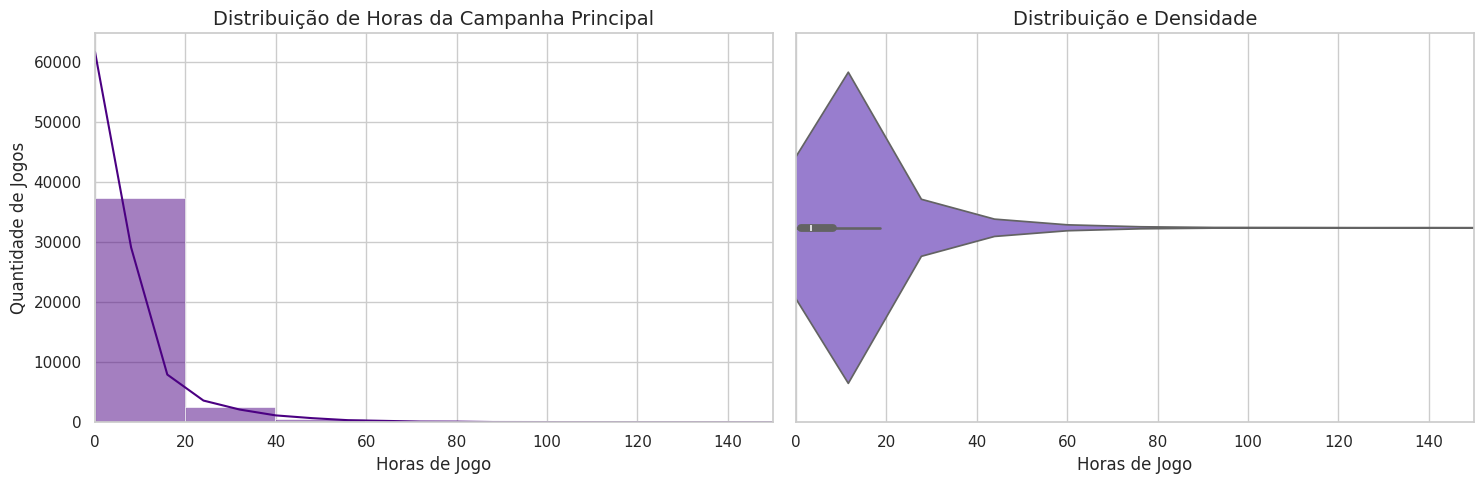

In [11]:
#Configurando a área dos gráficos (1 linha, 2 colunas)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

#Histograma: Mostra a concentração de jogos por faixa de horas
sns.histplot(Dados[TARGET], bins=80, kde=True, color='indigo', ax=ax[0])
ax[0].set_title('Distribuição de Horas da Campanha Principal', fontsize=14)
ax[0].set_xlabel('Horas de Jogo', fontsize=12)
ax[0].set_ylabel('Quantidade de Jogos', fontsize=12)
ax[0].set_xlim(0, 150)

#Violin Plot: Mostra a densidade dos dados e os extremos
sns.violinplot(x=Dados[TARGET], color='mediumpurple', ax=ax[1])
ax[1].set_title('Distribuição e Densidade', fontsize=14)
ax[1].set_xlabel('Horas de Jogo', fontsize=12)
ax[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

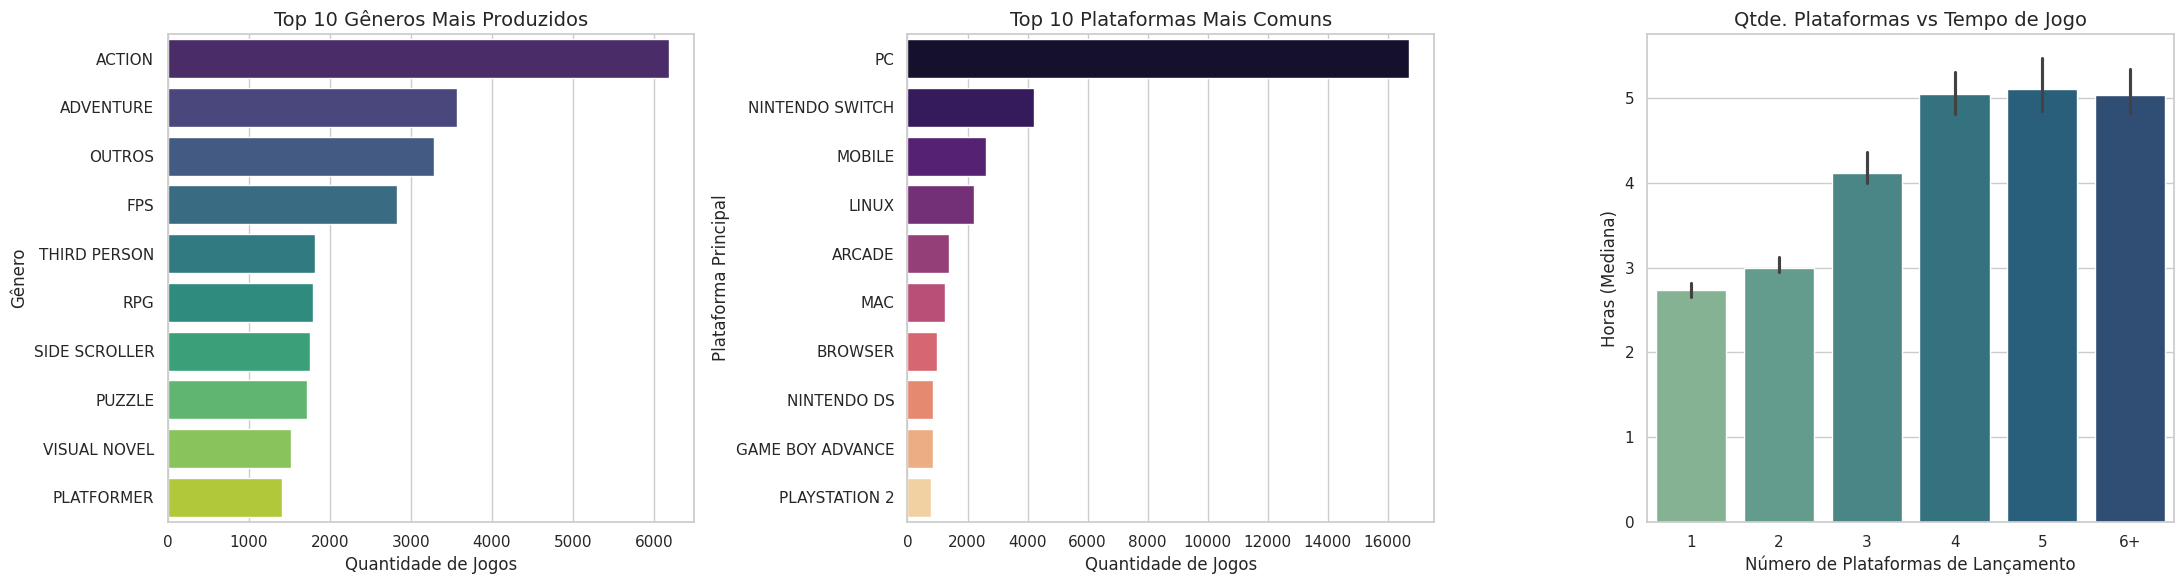

In [12]:
# Configurando a área dos gráficos para 3 painéis
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Top 10 Gêneros mais comuns
top_generos = Dados['genres'].value_counts().head(10)
sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis", ax=ax[0])
ax[0].set_title('Top 10 Gêneros Mais Produzidos', fontsize=14)
ax[0].set_xlabel('Quantidade de Jogos')
ax[0].set_ylabel('Gênero')

# Gráfico 2: Distribuição de Plataformas Principal
top_plats = Dados['platform'].value_counts().head(10)
sns.barplot(x=top_plats.values, y=top_plats.index, palette="magma", ax=ax[1])
ax[1].set_title('Top 10 Plataformas Mais Comuns', fontsize=14)
ax[1].set_xlabel('Quantidade de Jogos')
ax[1].set_ylabel('Plataforma Principal')

#Gráfico 3: Número de Plataformas vs Tempo de Jogo
#Ajuste na contagem das plataformas
dados_grafico = Dados.assign(
    num_plats_agrupado=Dados['num_plataformas'].apply(lambda x: str(x) if x <= 5 else '6+')
)
#Agrupar os jogos que tem mais de 6 plataformas de jogo para o grafico.
ordem = ['1', '2', '3', '4', '5', '6+']
sns.barplot(
    data=dados_grafico,
    x='num_plats_agrupado',
    y='main_story',
    estimator='median',
    order=ordem,
    palette="crest",
    ax=ax[2]
)
ax[2].set_title('Qtde. Plataformas vs Tempo de Jogo', fontsize=14)
ax[2].set_xlabel('Número de Plataformas de Lançamento')
ax[2].set_ylabel('Horas (Mediana)')

plt.tight_layout()
plt.show()

## 4.3 Relação entre variáveis e target <a id="ancora-4-3"></a>

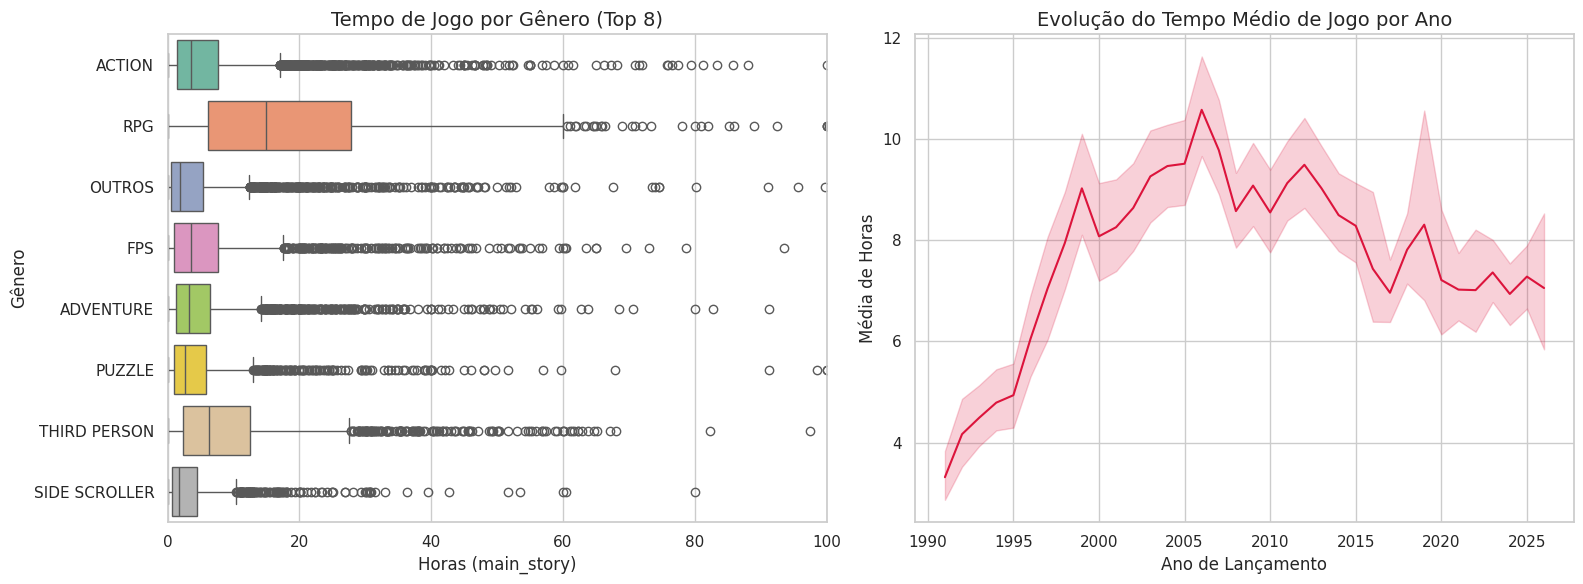

In [13]:
  #Configurando a área dos gráficos
  fig, ax = plt.subplots(1, 2, figsize=(16, 6))

  #Gráfico 1: Relação Gênero vs Tempo de Jogo entre os Top8
  top8_gen_names = Dados['genres'].value_counts().head(8).index
  df_top_gen = Dados[Dados['genres'].isin(top8_gen_names)]

  sns.boxplot(data=df_top_gen, x='main_story', y='genres', palette="Set2", ax=ax[0])
  ax[0].set_title('Tempo de Jogo por Gênero (Top 8)', fontsize=14)
  ax[0].set_xlabel('Horas (main_story)')
  ax[0].set_ylabel('Gênero')
  ax[0].set_xlim(0, 100)

  #Gráfico 2: Relação Ano de Lançamento vs Tempo de Jogo
  df_anos = Dados[Dados['release_year'] > 1990]
  sns.lineplot(data=df_anos, x='release_year', y='main_story', color='crimson', ax=ax[1])
  ax[1].set_title('Evolução do Tempo Médio de Jogo por Ano', fontsize=14)
  ax[1].set_xlabel('Ano de Lançamento')
  ax[1].set_ylabel('Média de Horas')

  plt.tight_layout()
  plt.show()

## 4.4 Conclusões da Análise e Hipóteses <a id="ancora-4-4"></a>
A partir da visualização dos dados, podemos destacar os seguintes padrões relevantes e levantar algumas hipóteses:

1. **Assimetria e Outliers:** A distribuição da variável alvo (`main_story`) é  concentrada à esquerda com a maioria dos jogos com duração de 5 a 15 horas. A longa cauda à direita do confirma a existência de muitos *outliers* que são jogos com mais de 100 horas de duração.
2. **Impacto do Gênero (Hipótese 1):** O cruzamento entre variáveis mostrou claramente que a categoria do jogo dita o tempo de desenvolvimento. Gêneros como `Role-Playing` possuem uma media de horas muito superior a jogos de `Action` ou `Platform`. Isso sugere que o algoritmo deverá dar muito peso à feature `genres` na hora de prever o tempo.
3. **Tendência Temporal (Hipótese 2):** A linha do tempo indica variações, mas percebe-se uma leve tendência de aumento na média de horas das campanhas principais a partir da década de 2000, possivelmente estabilizando ou apresentando picos na era mais moderna dos consoles, o que reflete a demanda do mercado por mundos maiores.
4. **Número de Plataformas (Hipótese 3):** A criação da métrica num_plataformas revelou uma correlação: a duração do jogo escalam conforme a abrangência do lançamento. Jogos lançados para um único console tendem a campanhas mais curtas, enquanto títulos multiplataforma apresentam uma mediana de horas significativamente maior, possivelmente a estratégia de distribuição está relacionada a quantidade de horas da campanha principal.

## 4.5 Síntese da análise exploratória <a id="ancora-4-5"></a>


**Síntese:**  
> A análise exploratória revelou que a variável alvo main_story apresenta forte assimetria à direita, com a grande massa de jogos concentrada entre 5 e 15 horas, acompanhada por uma longa cauda de outliers extremos, como RPGs de mais de 100 horas. Essa presença de valores atípicos e relações não-lineares entre categorias indica que algoritmos baseados em árvores, como o RandomForestRegressor, tendem a ter um desempenho superior. Durante o pré-processamento, registros sem a variável alvo foram descartados, enquanto valores nulos de gênero e plataforma foram preenchidos com "Desconhecido" e "Outros". A descoberta mais crítica da EDA foi a identificação de Data Leakage, o que mudou: variáveis pós-lançamento altamente correlacionadas como main_plus_sides e colunas de votação foram excluídas para evitar que o modelo aprenda dados futuros.


# 5.0 Preparação dos dados e divisão treino/teste


In [14]:
#Criando a lista de Features
features = [coluna for coluna in Dados.columns if coluna != TARGET]

print("--- Configuração do Modelo ---")
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features reais:", len(features))
print("Features utilizadas:", features)
print("-" * 40)

--- Configuração do Modelo ---
Tipo de problema: regressao
Target: main_story
Número de features reais: 6
Features utilizadas: ['type', 'platform', 'genres', 'publisher', 'release_year', 'num_plataformas']
----------------------------------------


## 5.1 Divisão dos dados

In [15]:
#Determinação dos features e TARGET
X = Dados[features]
y = Dados[TARGET]

#Separação do dados de Treino e dados de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

print("\n--- Divisão dos Dados ---")
print(f"Base Treino: {X_train.shape[0]} linhas")
print(f"Base Teste:  {X_test.shape[0]} linhas")



--- Divisão dos Dados ---
Base Treino: 32671 linhas
Base Teste:  8168 linhas


## 5.1 Justificativa da divisão

* **Estratégia de Divisão (Holdout):** Optei pela divisão clássica de Holdout, porque não irei utilizar divisão temporal.
* **A proporção foi definida como 80/20:** Devido ao tamanho do dataset, esta divisão garante volume suficiente para os algoritmos encontrem padrões complexos.
* **Prevenção contra Data Leakage:** O vazamento foi evitado na etapa de limpeza. Descartei todas as colunas que continham informações pós-lançamento, garantindo que o modelo não aprenda com dados do futuro.






# 6.0 Pré-processamento e pipeline

In [16]:
#Utilizando função para pré processamento
pre_processador, colunas_numericas, colunas_categorias = funcao_pre_processamento(X_train)

print("Analise:")
print(f"Colunas Numéricas: {len(colunas_numericas)}\nColunas Categoricas: {len(colunas_categorias)}\nTotal de colunas: {len(colunas_numericas) + len(colunas_categorias)}")

#Processando os dados de treino
X_train_processado = pre_processador.fit_transform(X_train)

#Processando os dados de teste
X_test_processado = pre_processador.transform(X_test)

print("\nDetalhes do pré processamento")
print("-"*20)
print(f"Formato original do X_train: {X_train.shape}")
print(f"Formato original do X_Test: {X_test.shape}")
print("-"*20)
#Atribui o novo valor processado
X_train = X_train_processado
X_test = X_test_processado
print(f"Novo formato do X_train_processado: {X_train_processado.shape}")
print(f"Novo formato do X_test_processado:  {X_test_processado.shape}")

Analise:
Colunas Numéricas: 2
Colunas Categoricas: 4
Total de colunas: 6

Detalhes do pré processamento
--------------------
Formato original do X_train: (32671, 6)
Formato original do X_Test: (8168, 6)
--------------------
Novo formato do X_train_processado: (32671, 267)
Novo formato do X_test_processado:  (8168, 267)


## 6.1 Conferência das Colunas Geradas

In [17]:
#Extraindo os nomes das colunas de dentro do motor

nomes_das_colunas = pre_processador.get_feature_names_out()
print(f"Total de colunas confirmadas: {len(nomes_das_colunas)}\n")

#Mostrando todas colunas geradas
for Colunas in nomes_das_colunas:
    print(Colunas)


Total de colunas confirmadas: 267

numeros__release_year
numeros__num_plataformas
textos__type_game
textos__platform_3DO
textos__platform_ACORN ARCHIMEDES
textos__platform_AMAZON LUNA
textos__platform_AMIGA
textos__platform_AMIGA CD32
textos__platform_AMSTRAD CPC
textos__platform_APPLE II
textos__platform_ARCADE
textos__platform_ATARI 2600
textos__platform_ATARI 5200
textos__platform_ATARI 7800
textos__platform_ATARI 8 BIT FAMILY
textos__platform_ATARI JAGUAR
textos__platform_ATARI JAGUAR CD
textos__platform_ATARI LYNX
textos__platform_ATARI ST
textos__platform_BBC MICRO
textos__platform_BROWSER
textos__platform_COLECOVISION
textos__platform_COMMODORE 64
textos__platform_COMMODORE PET
textos__platform_COMMODORE VIC 20
textos__platform_DESCONHECIDO
textos__platform_DREAMCAST
textos__platform_EMULATED
textos__platform_EVERCADE
textos__platform_FM 7
textos__platform_FM TOWNS
textos__platform_GAME & WATCH
textos__platform_GAME BOY
textos__platform_GAME BOY ADVANCE
textos__platform_GAME BOY

## 6.1 Decisões de pré-processamento

> Não utilizei nenhuma imputação, porque ja tratei os valores nulos na função de limpeza dos dados, foi necessario padronizar a coluna ano, devido ao problema de grandeza, usei o StandardScaler para evitar que fique muito discrepante o valor entre as colunas, não realizei nenhuma remoção no pré processamento, porque já havia retirado as colunas que irão me dar problema com Data Leakage e por ultimo utilizei o OneHotEncoder para criar novas colunas para representar os atributos das colunas Plataforma, gênero, publicadora e estarem disponivéis na previsão.


# 7.0 Baseline e modelos candidatos


## 7.1 Estabelecendo o Baseline

In [18]:
# Criação do modelo baseline para calcular a média
modelo_baseline = DummyRegressor(strategy='mean')

#Treinamento
modelo_baseline.fit(X_train_processado, y_train)

#Previsões
previsoes_baseline = modelo_baseline.predict(X_test_processado)

#Metricas do Baseline
erro_baseline = mean_absolute_error(y_test, previsoes_baseline)
r2_baseline = r2_score(y_test, previsoes_baseline)

print(f"O modelo Baseline erra em média: {erro_baseline:.2f} horas por jogo.")
print(f"R² do Baseline: {r2_baseline:.4f}")


O modelo Baseline erra em média: 7.16 horas por jogo.
R² do Baseline: -0.0000


## 7.2 Modelos Candidatos

In [19]:
#Definindo modelos candidatos
modelos_candidatos = {
    "Regressão Ridge": Ridge(random_state=42, alpha=1.0),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("Modelos prontos para o treinamento:")
for nome in modelos_candidatos.keys():
    print(f"- {nome}")

Modelos prontos para o treinamento:
- Regressão Ridge
- Árvore de Decisão
- Random Forest


## 7.4 Justificativa dos modelos
>O baseline escolhido é coerente porque, como estamos utilizando um modelo de regressão para prever horas jogadas, o simples cálculo da média já nos fornece uma nota de corte inicial para o desafio erro de 7.16 horas. Os modelos candidatos escolhidos trabalham muito bem com dados tabulares e se adequam perfeitamente a essa estrutura. Todos eles exigem o uso do OneHotEncoder para transformar categorias textuais em números, mas apenas o modelo Ridge exige a aplicação do StandardScaler para evitar distorções com a grandeza da escala na coluna de anos. Em relação às restrições, o Ridge e a Árvore de Decisão possuem ótima interpretabilidade e baixo custo de processamento. Por outro lado, o Random Forest possui baixa interpretabilidade e tem, por natureza, um custo computacional mais elevado

# 8.0 Treinamento e avaliação inicial


In [20]:
print("--- Treinamento dos Modelos ---")

resultados_lista = []
metricas = {}

#Estrutura para treinar todos os modelos
for nome, modelo in modelos_candidatos.items():
    print("\n")
    print("-"*40)
    print(f"Treinando o modelo: {nome}...")

    inicio = time.time()

    #Treino
    modelo.fit(X_train_processado, y_train)

    #Previsões
    previsoes_treino = modelo.predict(X_train_processado)
    previsoes_teste = modelo.predict(X_test_processado)

    fim = time.time()
    tempo_execucao = fim - inicio

    #Calculando as métricas do Treino
    mae_treino = mean_absolute_error(y_train, previsoes_treino)
    mse_treino = mean_squared_error(y_train, previsoes_treino)
    r2_treino = r2_score(y_train, previsoes_treino)

    #Calculando as métricas do Teste
    mae_teste = mean_absolute_error(y_test, previsoes_teste)
    mse_teste = mean_squared_error(y_test, previsoes_teste)
    r2_teste = r2_score(y_test, previsoes_teste)

    #Guardando os resultados
    resultados_lista.append({
        'Modelo': nome,
        'R2 TREINO': r2_treino,
        'R2 TESTE': r2_teste,
        'MAE Teste': mae_teste,
        'MAE Treino': mae_treino,
        'MSE Teste': mse_teste,
        'MSE Treino': mse_treino,
        'Tempo (s)': tempo_execucao
    })
    metricas[nome] = {
      'r2_treino': r2_treino,
      'r2_teste': r2_teste,
      'previsoes_teste': previsoes_teste
    }

    print(f"Resultado {nome}:")
    print("\n-- Comparação R² --")
    print(f" - R² TREINO: {r2_treino:.4f}")
    print(f" - R² TESTE:  {r2_teste:.4f}")
    print("\n-- Comparação MAE --")
    print(f" - MAE Treino: {mae_treino:.2f} horas")
    print(f" - MAE Teste: {mae_teste:.2f} horas")
    print("\n-- Comparação MSE --")
    print(f" - MSE Treino: {mse_treino:.2f}")
    print(f" - MSE Teste: {mse_teste:.2f}")
    print("\n-- Tempo de Execução --")
    print(f" - Tempo:     {tempo_execucao:.4f} segundos")
    print("-"*40)

#Criando o placar
df_resultados = pd.DataFrame(resultados_lista)
df_resultados = df_resultados.sort_values(by='MAE Teste', ascending=True)
print("\nPLACAR")
display(df_resultados)

--- Treinamento dos Modelos ---


----------------------------------------
Treinando o modelo: Regressão Ridge...
Resultado Regressão Ridge:

-- Comparação R² --
 - R² TREINO: 0.0868
 - R² TESTE:  0.0869

-- Comparação MAE --
 - MAE Treino: 5.98 horas
 - MAE Teste: 6.06 horas

-- Comparação MSE --
 - MSE Treino: 342.83
 - MSE Teste: 300.06

-- Tempo de Execução --
 - Tempo:     0.5015 segundos
----------------------------------------


----------------------------------------
Treinando o modelo: Árvore de Decisão...
Resultado Árvore de Decisão:

-- Comparação R² --
 - R² TREINO: 0.4462
 - R² TESTE:  -0.2461

-- Comparação MAE --
 - MAE Treino: 2.97 horas
 - MAE Teste: 6.84 horas

-- Comparação MSE --
 - MSE Treino: 207.89
 - MSE Teste: 409.50

-- Tempo de Execução --
 - Tempo:     1.9183 segundos
----------------------------------------


----------------------------------------
Treinando o modelo: Random Forest...
Resultado Random Forest:

-- Comparação R² --
 - R² TREINO: 0.3926
 - R

,Modelo,R2 TREINO,R2 TESTE,MAE Teste,MAE Treino,MSE Teste,MSE Treino,Tempo (s)
0,Regressão Ridge,0.086786,0.086926,6.060049,5.980272,300.058857,342.828176,0.501501
2,Random Forest,0.392650,-0.011496,6.190460,3.906716,332.402688,228.004364,90.604252
1,Árvore de Decisão,0.446224,-0.246092,6.836555,2.967909,409.496798,207.892050,1.918303


## 8.1 Análise dos resultados iniciais

> * **Superação do baseline:** Sim, os modelos conseguiram superar a nota de corte estabelecida pelo baseline. A Regressão Ridge apresentou o melhor desempenho geral, registrando um MAE de 6.06 horas na base de teste, superando a Random Forest 6.19 horas e a Árvore de Decisão 6.84 horas.

> * **Suficiência da métrica:** Para avaliar a capacidade de generalização de cada modelo com precisão, utilizei três métricas de forma combinada: MAE, MSE e R². Utilizar apenas o erro médio absoluto não seria suficiente para uma visão do todo. O cruzamento desses três indicadores garantiu não apenas a medição do erro prático, mas também a detecção de desvios e a validação do aprendizado real do algoritmo ao comparar o desempenho entre as bases de Treino e Teste pelo R².

> * **Underfitting e Overfitting:** Identifiquei dois problemas analisando as notas de R². O modelo Ridge sofre de underfitting mostrando que o R²  evidenciando que é simples demais para os dados. Já a Árvore de Decisão e o Random Forest demonstra que estão com overfitting: decoraram o treino demonstrado no R² positivo, mas falharam no teste  demonstrado no R² negativo.  Este comportamento tentaremos corrigir via ajuste de hiperparâmetros .

> * **Tempo de Treinamento:** Os tempos do Ridge e da Árvore  são excelentes e viáveis para implantação. Contudo, o tempo do Random Forest é inaceitável levando em consideração o custo-benefício, pois exige um esforço computacional centenas de vezes maior.

> * **Coerência com a EDA:** O resultado é um reflexo exato da Análise Exploratória. Como a variável de horas jogadas possui altíssima dispersão, outliers naturais e forte dependência do fator humano, é esperado que algoritmos baseados apenas em metadados de catálogo encontrem dificuldade matemática para prever essas horas com precisão.A alta cardinalidade de algumas variaveis como Publishers gera ruído e induz à memorização.




## 8.2 Tentativa de Correção do Underfitting do Ridge

In [21]:
print("--- Tentativa de Correção do Underfitting do Ridge ---")

#Aplicando o Logaritmo na variável horas para treino e teste
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

#Treinando um novo Ridge com os dados transformados
modelo_ridge_log = Ridge(random_state=42, alpha=1.0)
modelo_ridge_log.fit(X_train_processado, y_train_log)

#Previsões
previsoes_treino_log = modelo_ridge_log.predict(X_train_processado)
previsoes_teste_log = modelo_ridge_log.predict(X_test_processado)

#Revertendo o Log para calcular o erro em Horas Reais
previsoes_treino_reais = np.expm1(previsoes_treino_log)
previsoes_teste_reais = np.expm1(previsoes_teste_log)

#Calculando o R²
r2_treino_log = r2_score(y_train_log, previsoes_treino_log)
r2_teste_log = r2_score(y_test_log, previsoes_teste_log)

#Calculando o MAE
mae_Treino_log = mean_absolute_error(y_train, previsoes_treino_reais)
mae_teste_log = mean_absolute_error(y_test, previsoes_teste_reais)

print("\n-- Comparação R² --")
print(f" - R² TREINO: {r2_treino_log:.4f}")
print(f" - R² TESTE:  {r2_teste_log:.4f}")
print("\n-- Comparação MAE --")
print(f" - MAE Treino:  {mae_Treino_log:.2f} horas")
print(f" - MAE Teste:  {mae_teste_log:.2f} horas")

--- Tentativa de Correção do Underfitting do Ridge ---

-- Comparação R² --
 - R² TREINO: 0.3218
 - R² TESTE:  0.3202

-- Comparação MAE --
 - MAE Treino:  5.18 horas
 - MAE Teste:  5.22 horas


### 8.2.1 Analise Visual: Reta de Regressão

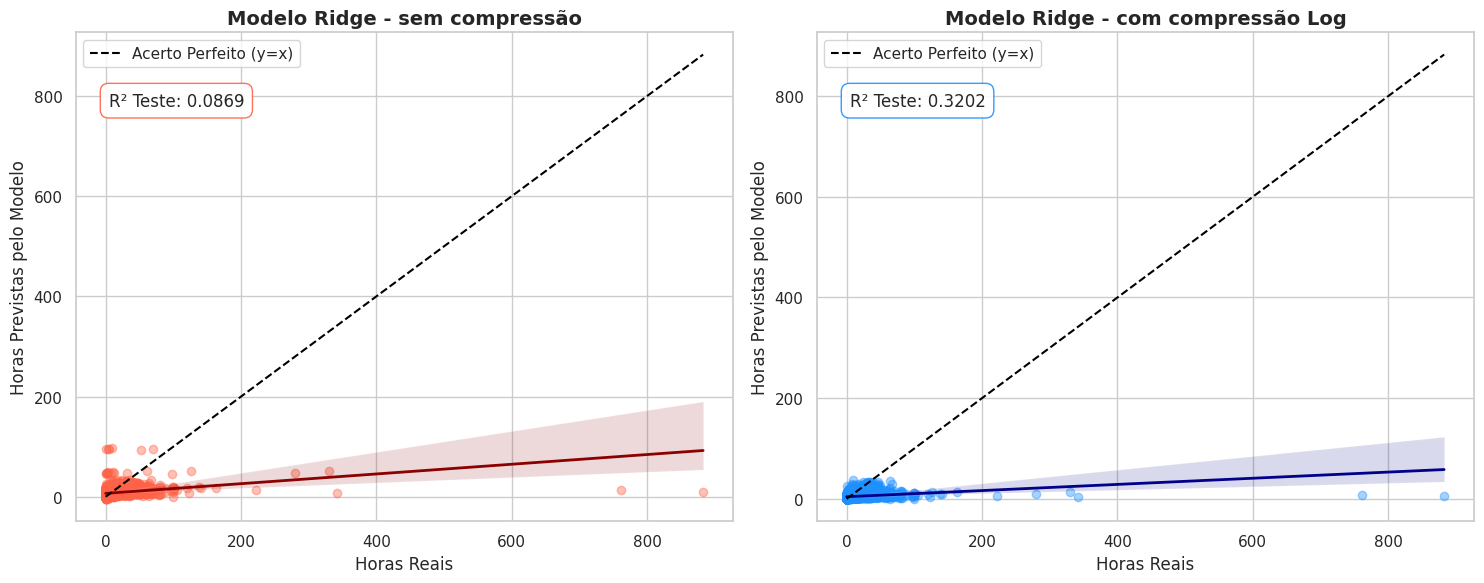

In [22]:
#Metricas do treinamento antes da correção
previsoes_teste_antigo = metricas['Regressão Ridge']['previsoes_teste']
r2_teste_antigo = metricas['Regressão Ridge']['r2_teste']

#Criando o quadro para os gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Calculando o limite do gráfico para desenhar a linha pontilhada perfeita
min_val = 0
max_val = y_test.max()

#GRÁFICO 1: Dados sem compressão
sns.regplot(x=y_test, y=previsoes_teste_antigo, ax=axes[0],
            color="tomato", scatter_kws={'alpha':0.4}, line_kws={'color':'darkred', 'linewidth':2})
axes[0].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Acerto Perfeito (y=x)')
axes[0].set_title('Modelo Ridge - sem compressão', fontsize=14, weight='bold')
axes[0].set_xlabel('Horas Reais', fontsize=12)
axes[0].set_ylabel('Horas Previstas pelo Modelo', fontsize=12)
axes[0].legend()

#Rotulo do R² antigo
texto_antes = f"R² Teste: {r2_teste_antigo:.4f}"
axes[0].text(0.05, 0.85, texto_antes, transform=axes[0].transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='tomato', boxstyle='round,pad=0.5'))

#GRÁFICO 2: Dados com compressão Log
sns.regplot(x=y_test, y=previsoes_teste_reais, ax=axes[1],
            color="dodgerblue", scatter_kws={'alpha':0.4}, line_kws={'color':'darkblue', 'linewidth':2})

#Linha preta pontilhada
axes[1].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Acerto Perfeito (y=x)')

axes[1].set_title('Modelo Ridge - com compressão Log', fontsize=14, weight='bold')
axes[1].set_xlabel('Horas Reais', fontsize=12)
axes[1].set_ylabel('Horas Previstas pelo Modelo', fontsize=12)
axes[1].legend()

#Rotulo do R² corrigido
texto_depois = f"R² Teste: {r2_teste_log:.4f}"
axes[1].text(0.05, 0.85, texto_depois, transform=axes[1].transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='dodgerblue', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

### 8.2.2 Analise da Correção do Underfitting do Modelo Ridge:

> Conforme a Análise Exploratória, a variável de horas possui uma distribuição muito assimétrica, com uma cauda longa à direita com outliers. Para resolver esse problema, apliquei a transformação logarítmica na variável alvo para comprimir esses valores extremos e aproximar os dados de uma distribuição normal. No gráfico de dispersão, é possível visualizar que a reta de regressão agora se ajusta melhor à massa principal de dados, demonstrando uma melhora direta na métrica de R²

# 9.0 Validação e otimização de hiperparâmetros




## 9.1 Otimização da Árvore de Decisões

In [23]:
print("--- Otimizando Árvore de Decisão ---")
inicio_ad = time.time()

#Definindo os parâmetros
param_grid_ad = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

#Definindo qual a melhor combinação de parametros
grid_ad = GridSearchCV(DecisionTreeRegressor(random_state=42),
                       param_grid_ad,
                       cv=5,
                       scoring='neg_mean_absolute_error',
                       n_jobs=-1
                       )

grid_ad.fit(X_train_processado, y_train)

#Atribui os melhores parametros localidos pelo GridSearchCV
modelo_ad_otimizado = grid_ad.best_estimator_

#Metricas:
#R²
r2_ad_treino_otimizado = r2_score(y_train, modelo_ad_otimizado.predict(X_train_processado))
r2_ad_teste_otimizado = r2_score(y_test, modelo_ad_otimizado.predict(X_test_processado))
# MAE
previsoes_ad_otimizado = modelo_ad_otimizado.predict(X_test_processado)
mae_ad_teste_otimizado = mean_absolute_error(y_test, previsoes_ad_otimizado)

#Resultados
print(f"Tempo: {(time.time() - inicio_ad):.2f}s")
print(f"Parâmetros escolhidos: {grid_ad.best_params_}")
print(f"MAE Teste: {mae_ad_teste_otimizado:.2f} horas")
print(f"R² Treino: {r2_ad_treino_otimizado:.4f}")
print(f"R² Teste: {r2_ad_teste_otimizado:.4f}")

--- Otimizando Árvore de Decisão ---
Tempo: 107.28s
Parâmetros escolhidos: {'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 5}
MAE Teste: 6.29 horas
R² Treino: 0.0981
R² Teste: 0.0327


## 9.2 Otimização da Random Forest

In [24]:
print("--- Otimizando Random Forest ---")
inicio_rf = time.time()

#Parâmetros
param_grid_rf = {
    'n_estimators': [50],
    'max_depth': [5, 10],
    'min_samples_split': [20]
}

#Descobrindo melhor combinação de parâmetros
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid_rf,
                       cv=5,
                       scoring='neg_mean_absolute_error',
                       n_jobs=-1
                       )
grid_rf.fit(X_train_processado, y_train)

#Atribuir melhor combinação dos parâmetros localizado pelo GridSearchCV
modelo_rf_otimizado = grid_rf.best_estimator_

#Metricas
#R²
r2_rf_treino_otimizado = r2_score(y_train, modelo_rf_otimizado.predict(X_train_processado))
r2_rf_teste_otimizado = r2_score(y_test, modelo_rf_otimizado.predict(X_test_processado))
#MAE
previsoes_rf_otimizado = modelo_rf_otimizado.predict(X_test_processado)
mae_rf_teste_otimizado = mean_absolute_error(y_test, previsoes_rf_otimizado)

#Resultados
print(f"Tempo: {(time.time() - inicio_rf):.2f}s")
print(f"Parâmetros Vencedores: {grid_rf.best_params_}")
print(f"MAE Teste: {mae_rf_teste_otimizado:.2f} horas")
print(f"R² Treino: {r2_rf_treino_otimizado:.4f}")
print(f"R² Teste: {r2_rf_teste_otimizado:.4f}")

--- Otimizando Random Forest ---
Tempo: 153.91s
Parâmetros Vencedores: {'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 50}
MAE Teste: 6.29 horas
R² Treino: 0.1009
R² Teste: 0.0674


--- Gráfico de Comprovação da otimização ---


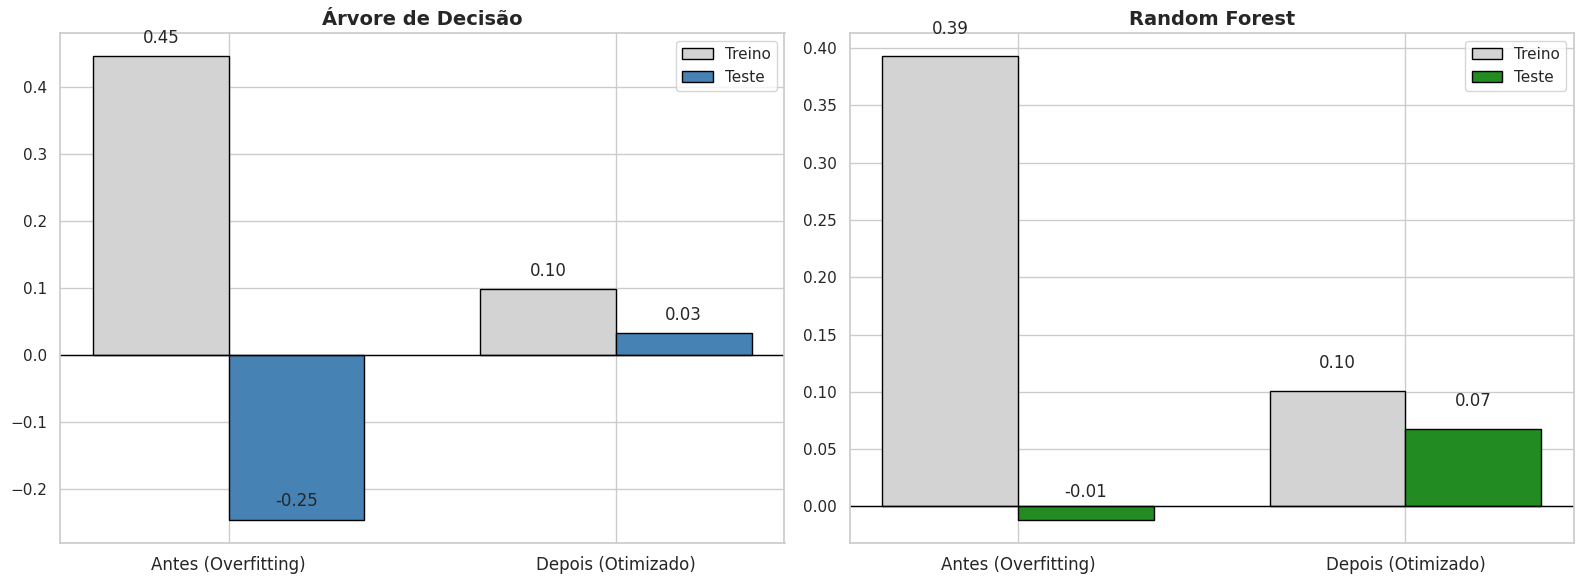

In [25]:
# Calculando o MAE do Random Forest Otimizado
previsoes_rf_otimizado = modelo_rf_otimizado.predict(X_test_processado)
mae_rf_teste_otimizado = mean_absolute_error(y_test, previsoes_rf_otimizado)

print("--- Gráfico de Comprovação da otimização ---")

r2_ad_treino_ruim = metricas['Árvore de Decisão']['r2_treino']
r2_ad_teste_ruim = metricas['Árvore de Decisão']['r2_teste']
r2_rf_treino_ruim = metricas['Random Forest']['r2_treino']
r2_rf_teste_ruim = metricas['Random Forest']['r2_teste']

# Desenhando o Gráfico (Lógica de barras)
labels = ['Antes (Overfitting)', 'Depois (Otimizado)']
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico Árvore de decisão ---
ad_treinos = [r2_ad_treino_ruim, r2_ad_treino_otimizado]
ad_testes = [r2_ad_teste_ruim, r2_ad_teste_otimizado]
axes[0].bar(x - width/2, ad_treinos, width, label='Treino', color='lightgray', edgecolor='black')
axes[0].bar(x + width/2, ad_testes, width, label='Teste', color='steelblue', edgecolor='black')
axes[0].set_title('Árvore de Decisão', fontsize=14, weight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend()
for i in range(2):
    axes[0].text(x[i] - width/2, ad_treinos[i] + 0.02, f"{ad_treinos[i]:.2f}", ha='center')
    axes[0].text(x[i] + width/2, ad_testes[i] + 0.02, f"{ad_testes[i]:.2f}", ha='center')

# --- Gráfico Random Forest ---
rf_treinos = [r2_rf_treino_ruim, r2_rf_treino_otimizado]
rf_testes = [r2_rf_teste_ruim, r2_rf_teste_otimizado]
axes[1].bar(x - width/2, rf_treinos, width, label='Treino', color='lightgray', edgecolor='black')
axes[1].bar(x + width/2, rf_testes, width, label='Teste', color='forestgreen', edgecolor='black')
axes[1].set_title('Random Forest', fontsize=14, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].legend()
for i in range(2):
    axes[1].text(x[i] - width/2, rf_treinos[i] + 0.02, f"{rf_treinos[i]:.2f}", ha='center')
    axes[1].text(x[i] + width/2, rf_testes[i] + 0.02, f"{rf_testes[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 9.2 Discussão da otimização
  
> * **A otimização melhorou o resultado em relação ao modelo inicial?**
Realizei a otimização em dois modelos, Árvore de Decisões e Random Forest. Utilizei o GridSearchCV para localizar quais seria a melhor combinação dos parâmetros para resolver o problema de overfitting. Foi possível testar vários cenários e otimizar os parâmetros da melhor maneira e com isso a otimização eliminou a diferença que existia entre as métricas de treino e teste, corrigindo o overfitting.

> * **A busca foi limitada por tempo, custo ou tamanho da base?**
Sim, a busca foi limitada por tempo e custo computacional. Principalmente devido ao uso de um algoritmo Ensemble baseado em árvores como o Random Forest, foi necessário diminuir a grade de testes do GridSearchCV e criar uma versão mais enxuta da otimização para viabilizar o tempo de execução do modelo.

> * **Os hiperparâmetros escolhidos fazem sentido?**
Fazem total sentido. Devido ao overfitting que estava ocorrendo no treinamento inicial dos modelos, limitar ao nivel 10 a profundidade da árvore e exigir pelo menos 20 amostras para criar uma nova ramificação que forçou o algoritmo a parar de procurar padrões isolados e específicos demais, focando na generalização.

> * **Você testaria outras combinações se tivesse mais tempo?**
Sim. Com maior capacidade computacional, seria possível testar mais parâmetros utilizando o GridSearchCV. Isso incluiria aumentar o número de estimadores, testar diferentes lógicas e critérios de métrica interna de corte da árvore, e ajustar como o modelo lida com as altas dispersões dos dados contínuos.


# 10.0 Avaliação final no conjunto de teste


In [26]:
print("--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")

#Calcula Metrica R² do teste do Modelo Escolhido
r2_ridge = r2_score(y_test, previsoes_teste_reais)

resultado_baseline = [
    {
        'Modelo': 'Baseline',
        'MAE Teste': erro_baseline,
        'R² Teste': round(r2_baseline)
    }
]
df_baseline = pd.DataFrame(resultado_baseline)
print("\nMetricas Modelo Baseline - DummyRegression")
display(df_baseline)
# Tabela:modelos treinados
resultados_modelos = [
    {
        'Modelo': 'Árvore de Decisão',
        'MAE Teste': mae_ad_teste_otimizado,
        'R² Teste': r2_ad_teste_otimizado
    },
    {
        'Modelo': 'Random Forest',
        'MAE Teste': mae_rf_teste_otimizado,
        'R² Teste': r2_rf_teste_otimizado
    },
    {
        'Modelo': 'Regressão Ridge',
        'MAE Teste': mae_teste_log,
        'R² Teste': r2_ridge
    }
]

df_modelos = pd.DataFrame(resultados_modelos)

# Ordenando do menor erro para o maior erro
df_modelos = df_modelos.sort_values(by='MAE Teste', ascending=True).reset_index(drop=True)
print("\nMetricas dos Modelos Candidatos")
display(df_modelos.style.highlight_min(subset=['MAE Teste'], color='lightgreen') \
                         .highlight_max(subset=['R² Teste'], color='lightgreen'))


#Modelo Escolhido
print("\n")
print("-" * 50)
print("\033[1mModelo Escolhido:\033[0m Regressão Ridge")
print("-" * 50)
print("\033[1mMetricas:\033[0m")
print(f" -> \033[1mMAE:\033[0m {mae_teste_log:.2f} horas de erro médio")
print(f" -> \033[1mR²:\033[0m  {r2_ridge:.4f}")
print("-" * 50)


--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---

Metricas Modelo Baseline - DummyRegression


,Modelo,MAE Teste,R² Teste
0,Baseline,7.164581,0



Metricas dos Modelos Candidatos


,Modelo,MAE Teste,R² Teste
0,Regressão Ridge,5.218878,0.052396
1,Árvore de Decisão,6.285661,0.032674
2,Random Forest,6.287778,0.067441




--------------------------------------------------
Modelo Escolhido: Regressão Ridge
--------------------------------------------------
Metricas:
 -> MAE: 5.22 horas de erro médio
 -> R²:  0.0524
--------------------------------------------------


## 10.1 Análise de erros e limitações

>* **Quais tipos de erro o modelo comete mais?**
O modelo tem maior dificuldade para prever a duração de jogos massivos que são os outliers. Mesmo após a aplicação do logaritmo para suavizar a distribuição dos jogos de escopo tradicional, o algoritmo ainda subestima as campanhas daqueles títulos que ultrapassam 100 horas de conteúdo.

>* **Há sinais de overfitting ou underfitting?**
Houve sinais de overfitting nos modelos baseados em árvore, problema que foi mitigado com a otimização de hiperparâmetros. A transformação logarítmica também ajudou a reduzir o underfitting do modelo Ridge. No entanto, como os metadados de entrada são simples, existe um limite estrutural que impede o modelo de alcançar uma melhor previsão.

>* **A métrica escolhida captura bem o objetivo do problema?**
Sim. O MAE demonstrou ser a melhor escolha para traduzir a performance do modelo em horas reais. Já a métrica R² serviu como uma ótima ferramenta para diagnosticar se o treinamento estava gerando bons resultados matemáticos.

>* **Há viés, limitações de dados ou risco de generalização?**
Existe uma forte limitação nos dados preditivos disponíveis. A ausência de variáveis como preço de lançamento, orçamento, multiplayer e etc.. estringe a capacidade do algoritmo. Consequentemente, o modelo generaliza muito bem para o cenário de jogos de escopo padrão em campanhas curtas e médias, mas perde acurácia ao tentar prever os grandes outliers da indústria.

# 11.0 Comparação final dos modelos

| Modelo | MAE |R²| Tempo de treino | Observações |
|---|---:|---:|---:|---|
| DummyRegression | 7.16 horas | 0.0000 | Instantâneo | Chute estatístico da média. Usado apenas como régua de referência. |
| Árvore de Decisão | 6.29 horas | 0.0327 | Rápido | Curado do overfitting inicial via GridSearch. |
| Random Forest | 6.29 horas | 0.0874 | Moderado | Apresentou o melhor R², mas exigiu mais processamento devido às múltiplas árvores. |
| Ridge | 5.22 horas | 0.0524 | Rápido |  Melhor precisão e baixo custo computacional |



# 12.0 Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Fixar Seed (`random_state=42`)** | É necessário garantir que as divisões de treino/teste e os sorteios internos dos algoritmos sejam sempre os mesmos. | Garantir a reprodutibilidade exata dos resultados para qualquer pessoa que rodar o caderno. |
| **Pré-processamento:** | As horas tinham distorção por outliers e a coluna Gênero estava em formato de texto. | O logaritmo ajustou a curva suavizando o peso dos outliers, enquanto o OneHotEncoder traduziu os textos para uma linguagem matemática. |
| **Testar Baseline, Árvores, Forest e Ridge** | O modelo baseline foi utilizado para encontrar a média limite para os modelos superarem. | Encontrar a arquitetura que entregasse o menor erro absoluto (MAE) na vida real. |
| **Otimizar Hiperparâmetros usando GridSearchCV** | Árvores e Florestas apresentaram overfitting grave com R² de Treino positivo e Teste negativo ao decorar o gabarito. | Podar o crescimento do modelo para forçar a generalização e evitar desempenho artificial. |
| **Descartar árvores sem poda e retas lineares puras** | Árvores profundas memorizavam ruídos e modelos lineares sem o logaritmo previam horas negativas devido aos *outliers*. | Limpar a arquitetura final, mantendo apenas a Regressão Ridge com logaritmo, que se provou o modelo mais estável. |
| **Uso do ambiente padrão do Google Colab** | O ecossistema em nuvem já possui todas as bibliotecas (Scikit-Learn, Pandas) pré-instaladas e prontas para uso. | Facilitar a execução do laboratório e o compartilhamento do código sem conflitos de instalação. |
| **Restringir previsões a jogos de escopo padrão (Limitação)** | Escassez extrema de variáveis preditivas de projeto como a falta de dados de orçamento, tamanho da equipe ou modo multiplayer. | Evitar previsões irreais ao tentar estimar a duração de jogos massivos com mais de 100 horas. |


# 13.0 Conclusão

**Conclusão:** Este MVP teve como objetivo prever a quantidade de horas da campanha principal de um jogo com base em 6 metadados de lançamento: Tipo, Plataforma, Gênero, Publisher, Ano de Lançamento e Número de Plataformas. A intenção era traçar o perfil de duração dos jogos.

Para chegar ao melhor algoritmo para este desafio, utilizei um modelo **DummyRegression** como *Baseline*, criando assim uma régua para medir o desempenho dos demais. Realizei o treinamento e ajustei os metadados conforme a exigência de cada modelo para conseguir reduzir o indicador MAE abaixo da nota de corte definida pelo *Baseline*.

O modelo escolhido foi a **Regressão Ridge**. Para isso foi necessário realizar uma transformação logarítmica na variável alvo. Depois que suavizei o peso das horas dos outliers, o modelo obteve o melhor resultado prático, cravando o MAE na marca de 5.22 horas de erro médio.

O **principal aprendizado** que tive foi que, ao longo do processo, precisamos sempre ficar de olho nas respostas das métricas para entender quais técnicas utilizar na resolução dos problemas que vão aparecendo durante o treinamento.

A **limitação do projeto** está nos próprios dados. Faltam variáveis cruciais para entender melhor o cenário de criação, como orçamento e prazo de desenvolvimento, que provavelmente são indicadores determinantes para o tamanho da campanha.

Os **próximos passos** seriam testar outros algoritmos mais modernos que facilitem a leitura das variáveis categóricas sem tanta conversão manual, buscando alcançar resultados ainda mais precisos.